In [ ]:
!pip install gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.9/279.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 4.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import h5py
import os
import torch
import gpytorch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from gpytorch.mlls import ExactMarginalLogLikelihood
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.model_selection import train_test_split
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
%matplotlib inline

from google.colab import drive
HOMED='/content/drive'
drive.mount(HOMED)

Mounted at /content/drive


Multi-Task Gaussian Process Regression for Alloy Properties

Loading training data from: /content/drive/MyDrive/Analyze4RHEA/support_points_10.csv
Loading test data from: /content/drive/MyDrive/Analyze4RHEA/alloy_plot_data_comprehensive.csv

Data summary:
  Training samples: 10
  Test samples: 4485 (excluded 10 training points)
  Total available samples: 4495

Feature space: 4 composition features
Target space: 2 properties (Formation Energy, Bulk Modulus)

Property ranges:
  Formation Energy: [-45.86, 0.90] eV
  Bulk Modulus: [81.51, 160.82] GPa

Training GP model on cpu...
------------------------------------------------------------
X_train shape: torch.Size([10, 4])
X_test shape: torch.Size([4485, 4])
y_train shape: torch.Size([10, 2])
y_test shape: torch.Size([4485, 2])
Iteration 10/200 - Loss: 1.375
Iteration 20/200 - Loss: 1.160
Iteration 30/200 - Loss: 0.990
Iteration 40/200 - Loss: 0.829
Iteration 50/200 - Loss: 0.643
Iteration 60/200 - Loss: 0.481
Iteration 70/200 - Loss: 0.39

/usr/local/lib/python3.12/dist-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


Plot saved to: /content/drive/MyDrive/Analyze4RHEA/SP/GPR_results_support_points_10.png


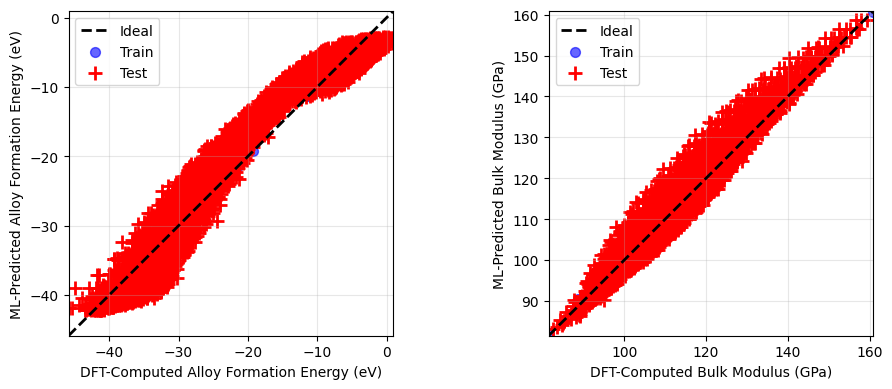


Model trainable parameters: 25
Multi-Task Gaussian Process Regression for Alloy Properties

Loading training data from: /content/drive/MyDrive/Analyze4RHEA/random_points_10.csv
Loading test data from: /content/drive/MyDrive/Analyze4RHEA/alloy_plot_data_comprehensive.csv

Data summary:
  Training samples: 10
  Test samples: 4485 (excluded 10 training points)
  Total available samples: 4495

Feature space: 4 composition features
Target space: 2 properties (Formation Energy, Bulk Modulus)

Property ranges:
  Formation Energy: [-45.86, 0.90] eV
  Bulk Modulus: [81.51, 160.82] GPa

Training GP model on cpu...
------------------------------------------------------------
X_train shape: torch.Size([10, 4])
X_test shape: torch.Size([4485, 4])
y_train shape: torch.Size([10, 2])
y_test shape: torch.Size([4485, 2])
Iteration 10/200 - Loss: 1.364
Iteration 20/200 - Loss: 1.008
Iteration 30/200 - Loss: 0.751
Iteration 40/200 - Loss: 0.507
Iteration 50/200 - Loss: 0.300
Iteration 60/200 - Loss: 0.14

/usr/local/lib/python3.12/dist-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


Plot saved to: /content/drive/MyDrive/Analyze4RHEA/SP/GPR_results_random_points_10.png


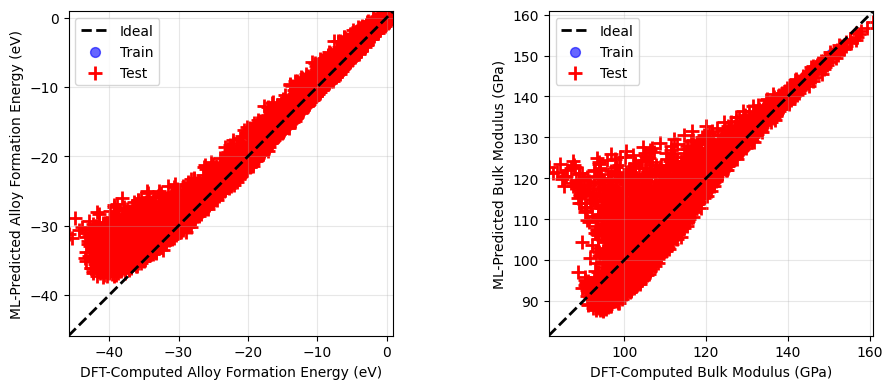


Model trainable parameters: 25


In [ ]:
# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_ITERS = 200

# User Configuration: Select which training file to use
TRAIN_FILE = 'support_points.csv'  # Options: 'support_points.csv' or 'random_points.csv'
TEST_FILE = 'alloy_plot_data_comprehensive.csv'


class MultitaskGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, tasks):
        super(MultitaskGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.MultitaskMean(
            gpytorch.means.ConstantMean(), num_tasks=tasks
        )

        self.covar_module = gpytorch.kernels.LCMKernel(
            [gpytorch.kernels.RBFKernel(ard_num_dims=train_x.shape[1]),
             gpytorch.kernels.RBFKernel(ard_num_dims=train_x.shape[1])],
             num_tasks=tasks, rank=tasks
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)


def train_GPR(X_train, X_test, y_train, y_test, x_scaler, y_scaler, start=None, stop=None, tname=None):
    """Train multi-task GP model"""

    X_train = torch.FloatTensor(x_scaler.transform(X_train)).to(DEVICE)
    y_train = torch.FloatTensor(y_scaler.transform(y_train)).to(DEVICE)

    X_test = torch.FloatTensor(x_scaler.transform(X_test)).to(DEVICE)
    y_test = torch.FloatTensor(y_scaler.transform(y_test)).to(DEVICE)

    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_test shape: {y_test.shape}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=2).to(device)
    model = MultitaskGPModel(X_train, y_train, likelihood, 2).to(device)

    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    # Training loop
    for i in range(TRAIN_ITERS):
        optimizer.zero_grad()
        output = model(X_train)
        loss = -mll(output, y_train)
        loss.backward()
        optimizer.step()

        if (i + 1) % 10 == 0:
            print(f"Iteration {i+1}/{TRAIN_ITERS} - Loss: {loss.item():.3f}")

    # Evaluate on training set
    model.eval()
    likelihood.eval()

    with torch.no_grad():
        preds = likelihood(model(X_train))

    preds = y_scaler.inverse_transform(preds.mean.cpu().detach().numpy())
    y_train_inv = y_scaler.inverse_transform(y_train.cpu().detach().numpy())

    # Evaluate on test set
    with torch.no_grad():
        preds_test = likelihood(model(X_test))

    preds_test = y_scaler.inverse_transform(preds_test.mean.cpu().detach().numpy())
    y_test_inv = y_scaler.inverse_transform(y_test.cpu().detach().numpy())

    # Calculate and display metrics
    train_mae, train_mse, train_rmse, train_mape, train_nmae = calculate_metrics(y_train_inv, preds)
    test_mae, test_mse, test_rmse, test_mape, test_nmae = calculate_metrics(y_test_inv, preds_test)

    print("\n" + "="*60)
    print("BULK MODULUS (GPa)")
    print("="*60)
    print(f"Training   - MAE: {train_mae[1]:.3f} | RMSE: {train_rmse[1]:.3f} | MAPE: {train_mape[1]:.2f}% | NMAE: {train_nmae[1]:.2f}%")
    print(f"Testing    - MAE: {test_mae[1]:.3f} | RMSE: {test_rmse[1]:.3f} | MAPE: {test_mape[1]:.2f}% | NMAE: {test_nmae[1]:.2f}%")

    print("\n" + "="*60)
    print("ALLOY FORMATION ENERGY (eV)")
    print("="*60)
    print(f"Training   - MAE: {train_mae[0]:.3f} | RMSE: {train_rmse[0]:.3f} | MAPE: {train_mape[0]:.2f}% | NMAE: {train_nmae[0]:.2f}%")
    print(f"Testing    - MAE: {test_mae[0]:.3f} | RMSE: {test_rmse[0]:.3f} | MAPE: {test_mape[0]:.2f}% | NMAE: {test_nmae[0]:.2f}%")
    print("="*60 + "\n")

    # Create parity plots
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # Formation Energy plot
    axs[0].plot([start[0], stop[0]], [start[0], stop[0]],
                linestyle='--', linewidth=2, color='black', label='Ideal')
    axs[0].scatter(y_train_inv[:,0], preds[:,0], label='Train',
                  color='blue', alpha=0.6, s=50)
    axs[0].scatter(y_test_inv[:,0], preds_test[:,0], label='Test',
                  color='red', marker='+', s=100, linewidths=2)
    axs[0].set_xlabel('DFT-Computed Alloy Formation Energy (eV)')
    axs[0].set_ylabel('ML-Predicted Alloy Formation Energy (eV)')
    axs[0].set_xlim(start[0], stop[0])
    axs[0].set_ylim(start[0], stop[0])
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # Bulk Modulus plot
    axs[1].plot([start[1], stop[1]], [start[1], stop[1]],
                linestyle='--', linewidth=2, color='black', label='Ideal')
    axs[1].scatter(y_train_inv[:,1], preds[:,1], label='Train',
                  color='blue', alpha=0.6, s=50)
    axs[1].scatter(y_test_inv[:,1], preds_test[:,1], label='Test',
                  color='red', marker='+', s=100, linewidths=2)
    axs[1].set_xlabel('DFT-Computed Bulk Modulus (GPa)')
    axs[1].set_ylabel('ML-Predicted Bulk Modulus (GPa)')
    axs[1].set_xlim(start[1], stop[1])
    axs[1].set_ylim(start[1], stop[1])
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    for ax in axs.flat:
        ax.set_box_aspect(1)

    plt.tight_layout()

    # Save with descriptive filename
    train_name = TRAIN_FILE.replace('.csv', '').replace('_points', '')
    save_path = os.path.join(SAVED, f'GPR_results_{tname}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {save_path}")
    plt.show()

    return model.eval(), likelihood.eval(), preds_test


def calculate_metrics(y_true, y_pred):
    """
    Calculates regression metrics for one or more properties (columns).

    Args:
        y_true (np.array): Ground truth values. Shape (n_samples, n_properties)
        y_pred (np.array): Predicted values. Shape (n_samples, n_properties)

    Returns:
        tuple: A tuple containing arrays (one value per property) for
               (mae, mse, rmse, mape, nmae)
    """
    epsilon = 1e-10

    mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
    mse = mean_squared_error(y_true, y_pred, multioutput='raw_values')
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon)), axis=0) * 100
    nmae = mae / (np.mean(np.abs(y_true), axis=0) + epsilon) * 100

    return mae, mse, rmse, mape, nmae


def count_parameters(model):
    """Count trainable parameters in model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def create_composition_key(row):
    """Create a unique key from composition percentages for matching"""
    return f"{row['Zr_Percent']:.3f}_{row['Ti_Percent']:.3f}_{row['Nb_Percent']:.3f}_{row['Al_Percent']:.3f}"


def load_and_prepare_data(train_file, test_file):
    """
    Load training and test data from CSV files.

    Args:
        train_file: CSV file with training data (support_points.csv or random_points.csv)
        test_file: CSV file with all data (alloy_plot_data_comprehensive.csv)

    Returns:
        X_train, X_test, y_train, y_test: numpy arrays
    """
    print(f"\nLoading training data from: {train_file}")
    train_df = pd.read_csv(train_file)

    print(f"Loading test data from: {test_file}")
    test_df_all = pd.read_csv(test_file)

    # Create composition keys for matching
    train_df['comp_key'] = train_df.apply(create_composition_key, axis=1)
    test_df_all['comp_key'] = test_df_all.apply(create_composition_key, axis=1)

    # Get training keys to exclude from test set
    train_keys = set(train_df['comp_key'].tolist())

    # Filter test set to exclude training points
    test_df = test_df_all[~test_df_all['comp_key'].isin(train_keys)].copy()

    print(f"\nData summary:")
    print(f"  Training samples: {len(train_df)}")
    print(f"  Test samples: {len(test_df)} (excluded {len(train_keys)} training points)")
    print(f"  Total available samples: {len(test_df_all)}")

    # Extract features (last 4 columns: composition percentages)
    # Extract targets (first 2 columns: Formation_Energy, Bulk_Modulus)
    X_train = train_df[['Zr_Percent', 'Ti_Percent', 'Nb_Percent', 'Al_Percent']].values
    y_train = train_df[['Formation_Energy', 'Bulk_Modulus']].values

    X_test = test_df[['Zr_Percent', 'Ti_Percent', 'Nb_Percent', 'Al_Percent']].values
    y_test = test_df[['Formation_Energy', 'Bulk_Modulus']].values

    print(f"\nFeature space: {X_train.shape[1]} composition features")
    print(f"Target space: {y_train.shape[1]} properties (Formation Energy, Bulk Modulus)")

    return X_train, X_test, y_train, y_test


if __name__ == "__main__":
    HOME = os.path.join(HOMED,'MyDrive','Analyze4RHEA')
    SAVED = os.path.join(HOME,'SP')
    ndesign = 10
    TRAIN = f'support_points_{ndesign}.csv' #'support_points_{ndesign}.csv'  # or 'random_points_{ndesign}.csv'
    TEST = 'alloy_plot_data_comprehensive.csv'
    TRAIN_FILE = os.path.join(HOME,TRAIN) #'support_points.csv'  # or 'random_points.csv'
    TEST_FILE = os.path.join(HOME,TEST)

    print("="*60)
    print("Multi-Task Gaussian Process Regression for Alloy Properties")
    print("="*60)

    # Load and prepare data
    X_train, X_test, y_train, y_test = load_and_prepare_data(TRAIN_FILE, TEST_FILE)

    # Fit scalers
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train)

    # Get data ranges for plotting
    y_all = np.vstack([y_train, y_test])
    start = [y_all[:,0].min(), y_all[:,1].min()]
    stop = [y_all[:,0].max(), y_all[:,1].max()]

    print(f"\nProperty ranges:")
    print(f"  Formation Energy: [{start[0]:.2f}, {stop[0]:.2f}] eV")
    print(f"  Bulk Modulus: [{start[1]:.2f}, {stop[1]:.2f}] GPa")

    # Train forward model (p(y|x))
    print(f"\nTraining GP model on {DEVICE}...")
    print("-"*60)
    gpr_model, gpr_likelihood, y_pred_test = train_GPR(
        X_train, X_test, y_train, y_test,
        x_scaler, y_scaler,
        start=start, stop=stop,
        tname=TRAIN.replace('.csv', '')
    )

    total_params = count_parameters(gpr_model)
    print(f"\nModel trainable parameters: {total_params}")
    print("="*60)

    TRAIN = f'random_points_{ndesign}.csv' #'support_points_{ndesign}.csv'  # or 'random_points_{ndesign}.csv'
    TEST = 'alloy_plot_data_comprehensive.csv'
    TRAIN_FILE = os.path.join(HOME,TRAIN) #'support_points.csv'  # or 'random_points.csv'
    TEST_FILE = os.path.join(HOME,TEST)

    print("="*60)
    print("Multi-Task Gaussian Process Regression for Alloy Properties")
    print("="*60)

    # Load and prepare data
    X_train, X_test, y_train, y_test = load_and_prepare_data(TRAIN_FILE, TEST_FILE)

    # Fit scalers
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train)

    # Get data ranges for plotting
    y_all = np.vstack([y_train, y_test])
    start = [y_all[:,0].min(), y_all[:,1].min()]
    stop = [y_all[:,0].max(), y_all[:,1].max()]

    print(f"\nProperty ranges:")
    print(f"  Formation Energy: [{start[0]:.2f}, {stop[0]:.2f}] eV")
    print(f"  Bulk Modulus: [{start[1]:.2f}, {stop[1]:.2f}] GPa")

    # Train forward model (p(y|x))
    print(f"\nTraining GP model on {DEVICE}...")
    print("-"*60)
    gpr_model, gpr_likelihood, y_pred_test = train_GPR(
        X_train, X_test, y_train, y_test,
        x_scaler, y_scaler,
        start=start, stop=stop,
        tname=TRAIN.replace('.csv', '')
    )

    total_params = count_parameters(gpr_model)
    print(f"\nModel trainable parameters: {total_params}")
    print("="*60)

Multi-Task Gaussian Process Regression for Alloy Properties

Loading training data from: /content/drive/MyDrive/Analyze4RHEA/support_points__50.csv
Loading test data from: /content/drive/MyDrive/Analyze4RHEA/alloy_plot_data_comprehensive.csv

Data summary:
  Training samples: 50
  Test samples: 4445 (excluded 50 training points)
  Total available samples: 4495

Feature space: 4 composition features
Target space: 2 properties (Formation Energy, Bulk Modulus)

Property ranges:
  Formation Energy: [-45.86, 0.90] eV
  Bulk Modulus: [81.51, 160.82] GPa

Training GP model on cpu...
------------------------------------------------------------
X_train shape: torch.Size([50, 4])
X_test shape: torch.Size([4445, 4])
y_train shape: torch.Size([50, 2])
y_test shape: torch.Size([4445, 2])
Iteration 10/200 - Loss: 1.046
Iteration 20/200 - Loss: 0.617
Iteration 30/200 - Loss: 0.203
Iteration 40/200 - Loss: -0.204
Iteration 50/200 - Loss: -0.575
Iteration 60/200 - Loss: -0.868
Iteration 70/200 - Loss: 

/usr/local/lib/python3.12/dist-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(



BULK MODULUS (GPa)
Training   - MAE: 0.454 | RMSE: 0.640 | MAPE: 0.44% | NMAE: 0.41%
Testing    - MAE: 0.787 | RMSE: 1.012 | MAPE: 0.72% | NMAE: 0.71%

ALLOY FORMATION ENERGY (eV)
Training   - MAE: 0.268 | RMSE: 0.362 | MAPE: 5.33% | NMAE: 1.70%
Testing    - MAE: 0.525 | RMSE: 0.668 | MAPE: 6.38% | NMAE: 2.49%

Plot saved to: /content/drive/MyDrive/Analyze4RHEA/SP/GPR_results_support_points__50.png


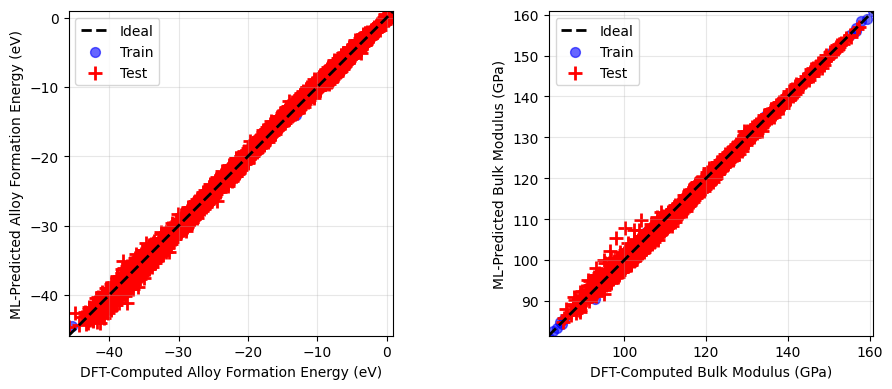


Model trainable parameters: 25
Multi-Task Gaussian Process Regression for Alloy Properties

Loading training data from: /content/drive/MyDrive/Analyze4RHEA/random_points__50.csv
Loading test data from: /content/drive/MyDrive/Analyze4RHEA/alloy_plot_data_comprehensive.csv

Data summary:
  Training samples: 50
  Test samples: 4445 (excluded 50 training points)
  Total available samples: 4495

Feature space: 4 composition features
Target space: 2 properties (Formation Energy, Bulk Modulus)

Property ranges:
  Formation Energy: [-45.86, 0.90] eV
  Bulk Modulus: [81.51, 160.82] GPa

Training GP model on cpu...
------------------------------------------------------------
X_train shape: torch.Size([50, 4])
X_test shape: torch.Size([4445, 4])
y_train shape: torch.Size([50, 2])
y_test shape: torch.Size([4445, 2])
Iteration 10/200 - Loss: 1.155
Iteration 20/200 - Loss: 0.677
Iteration 30/200 - Loss: 0.238
Iteration 40/200 - Loss: -0.170
Iteration 50/200 - Loss: -0.531
Iteration 60/200 - Loss: -

/usr/local/lib/python3.12/dist-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


Plot saved to: /content/drive/MyDrive/Analyze4RHEA/SP/GPR_results_random_points__50.png


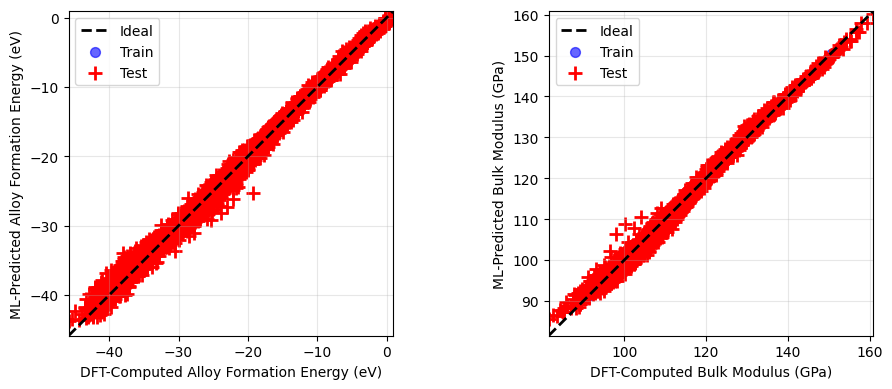


Model trainable parameters: 25


In [ ]:

    ndesign = 50
    TRAIN = f'support_points__{ndesign}.csv' #'support_points_{ndesign}.csv'  # or 'random_points_{ndesign}.csv'
    TEST = 'alloy_plot_data_comprehensive.csv'
    TRAIN_FILE = os.path.join(HOME,TRAIN) #'support_points.csv'  # or 'random_points.csv'
    TEST_FILE = os.path.join(HOME,TEST)

    print("="*60)
    print("Multi-Task Gaussian Process Regression for Alloy Properties")
    print("="*60)

    # Load and prepare data
    X_train, X_test, y_train, y_test = load_and_prepare_data(TRAIN_FILE, TEST_FILE)

    # Fit scalers
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train)

    # Get data ranges for plotting
    y_all = np.vstack([y_train, y_test])
    start = [y_all[:,0].min(), y_all[:,1].min()]
    stop = [y_all[:,0].max(), y_all[:,1].max()]

    print(f"\nProperty ranges:")
    print(f"  Formation Energy: [{start[0]:.2f}, {stop[0]:.2f}] eV")
    print(f"  Bulk Modulus: [{start[1]:.2f}, {stop[1]:.2f}] GPa")

    # Train forward model (p(y|x))
    print(f"\nTraining GP model on {DEVICE}...")
    print("-"*60)
    gpr_model, gpr_likelihood, y_pred_test = train_GPR(
        X_train, X_test, y_train, y_test,
        x_scaler, y_scaler,
        start=start, stop=stop,
        tname=TRAIN.replace('.csv', '')
    )

    total_params = count_parameters(gpr_model)
    print(f"\nModel trainable parameters: {total_params}")
    print("="*60)

    TRAIN = f'random_points__{ndesign}.csv' #'support_points_{ndesign}.csv'  # or 'random_points_{ndesign}.csv'
    TEST = 'alloy_plot_data_comprehensive.csv'
    TRAIN_FILE = os.path.join(HOME,TRAIN) #'support_points.csv'  # or 'random_points.csv'
    TEST_FILE = os.path.join(HOME,TEST)

    print("="*60)
    print("Multi-Task Gaussian Process Regression for Alloy Properties")
    print("="*60)

    # Load and prepare data
    X_train, X_test, y_train, y_test = load_and_prepare_data(TRAIN_FILE, TEST_FILE)

    # Fit scalers
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train)

    # Get data ranges for plotting
    y_all = np.vstack([y_train, y_test])
    start = [y_all[:,0].min(), y_all[:,1].min()]
    stop = [y_all[:,0].max(), y_all[:,1].max()]

    print(f"\nProperty ranges:")
    print(f"  Formation Energy: [{start[0]:.2f}, {stop[0]:.2f}] eV")
    print(f"  Bulk Modulus: [{start[1]:.2f}, {stop[1]:.2f}] GPa")

    # Train forward model (p(y|x))
    print(f"\nTraining GP model on {DEVICE}...")
    print("-"*60)
    gpr_model, gpr_likelihood, y_pred_test = train_GPR(
        X_train, X_test, y_train, y_test,
        x_scaler, y_scaler,
        start=start, stop=stop,
        tname=TRAIN.replace('.csv', '')
    )

    total_params = count_parameters(gpr_model)
    print(f"\nModel trainable parameters: {total_params}")
    print("="*60)

Multi-Task Gaussian Process Regression for Alloy Properties

Loading training data from: /content/drive/MyDrive/Analyze4RHEA/support_points__20.csv
Loading test data from: /content/drive/MyDrive/Analyze4RHEA/alloy_plot_data_comprehensive.csv

Data summary:
  Training samples: 20
  Test samples: 4475 (excluded 20 training points)
  Total available samples: 4495

Feature space: 4 composition features
Target space: 2 properties (Formation Energy, Bulk Modulus)

Property ranges:
  Formation Energy: [-45.86, 0.90] eV
  Bulk Modulus: [81.51, 160.82] GPa

Training GP model on cpu...
------------------------------------------------------------
X_train shape: torch.Size([20, 4])
X_test shape: torch.Size([4475, 4])
y_train shape: torch.Size([20, 2])
y_test shape: torch.Size([4475, 2])
Iteration 10/200 - Loss: 1.236
Iteration 20/200 - Loss: 0.864
Iteration 30/200 - Loss: 0.501
Iteration 40/200 - Loss: 0.209
Iteration 50/200 - Loss: -0.004
Iteration 60/200 - Loss: -0.163
Iteration 70/200 - Loss: -

/usr/local/lib/python3.12/dist-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


Plot saved to: /content/drive/MyDrive/Analyze4RHEA/SP/GPR_results_support_points__20.png


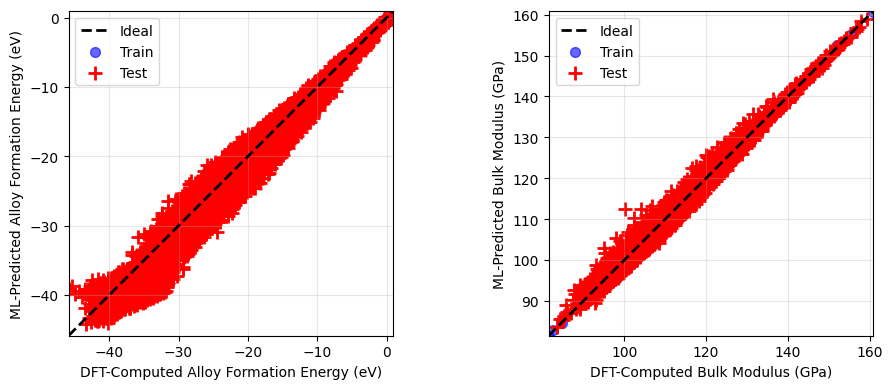


Model trainable parameters: 25
Multi-Task Gaussian Process Regression for Alloy Properties

Loading training data from: /content/drive/MyDrive/Analyze4RHEA/random_points__20.csv
Loading test data from: /content/drive/MyDrive/Analyze4RHEA/alloy_plot_data_comprehensive.csv

Data summary:
  Training samples: 20
  Test samples: 4475 (excluded 20 training points)
  Total available samples: 4495

Feature space: 4 composition features
Target space: 2 properties (Formation Energy, Bulk Modulus)

Property ranges:
  Formation Energy: [-45.86, 0.90] eV
  Bulk Modulus: [81.51, 160.82] GPa

Training GP model on cpu...
------------------------------------------------------------
X_train shape: torch.Size([20, 4])
X_test shape: torch.Size([4475, 4])
y_train shape: torch.Size([20, 2])
y_test shape: torch.Size([4475, 2])
Iteration 10/200 - Loss: 1.341
Iteration 20/200 - Loss: 0.890
Iteration 30/200 - Loss: 0.534
Iteration 40/200 - Loss: 0.207
Iteration 50/200 - Loss: -0.056
Iteration 60/200 - Loss: -0

/usr/local/lib/python3.12/dist-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(



BULK MODULUS (GPa)
Training   - MAE: 0.116 | RMSE: 0.142 | MAPE: 0.10% | NMAE: 0.10%
Testing    - MAE: 1.126 | RMSE: 1.434 | MAPE: 1.04% | NMAE: 1.02%

ALLOY FORMATION ENERGY (eV)
Training   - MAE: 0.138 | RMSE: 0.197 | MAPE: 1.10% | NMAE: 0.65%
Testing    - MAE: 0.749 | RMSE: 1.130 | MAPE: 24.99% | NMAE: 3.56%

Plot saved to: /content/drive/MyDrive/Analyze4RHEA/SP/GPR_results_random_points__20.png


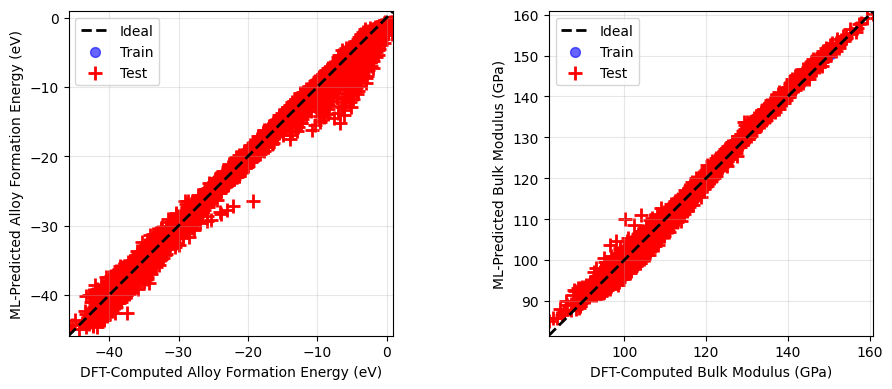


Model trainable parameters: 25


In [ ]:

    ndesign = 20
    TRAIN = f'support_points__{ndesign}.csv' #'support_points_{ndesign}.csv'  # or 'random_points_{ndesign}.csv'
    TEST = 'alloy_plot_data_comprehensive.csv'
    TRAIN_FILE = os.path.join(HOME,TRAIN) #'support_points.csv'  # or 'random_points.csv'
    TEST_FILE = os.path.join(HOME,TEST)

    print("="*60)
    print("Multi-Task Gaussian Process Regression for Alloy Properties")
    print("="*60)

    # Load and prepare data
    X_train, X_test, y_train, y_test = load_and_prepare_data(TRAIN_FILE, TEST_FILE)

    # Fit scalers
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train)

    # Get data ranges for plotting
    y_all = np.vstack([y_train, y_test])
    start = [y_all[:,0].min(), y_all[:,1].min()]
    stop = [y_all[:,0].max(), y_all[:,1].max()]

    print(f"\nProperty ranges:")
    print(f"  Formation Energy: [{start[0]:.2f}, {stop[0]:.2f}] eV")
    print(f"  Bulk Modulus: [{start[1]:.2f}, {stop[1]:.2f}] GPa")

    # Train forward model (p(y|x))
    print(f"\nTraining GP model on {DEVICE}...")
    print("-"*60)
    gpr_model, gpr_likelihood, y_pred_test = train_GPR(
        X_train, X_test, y_train, y_test,
        x_scaler, y_scaler,
        start=start, stop=stop,
        tname=TRAIN.replace('.csv', '')
    )

    total_params = count_parameters(gpr_model)
    print(f"\nModel trainable parameters: {total_params}")
    print("="*60)

    TRAIN = f'random_points__{ndesign}.csv' #'support_points_{ndesign}.csv'  # or 'random_points_{ndesign}.csv'
    TEST = 'alloy_plot_data_comprehensive.csv'
    TRAIN_FILE = os.path.join(HOME,TRAIN) #'support_points.csv'  # or 'random_points.csv'
    TEST_FILE = os.path.join(HOME,TEST)

    print("="*60)
    print("Multi-Task Gaussian Process Regression for Alloy Properties")
    print("="*60)

    # Load and prepare data
    X_train, X_test, y_train, y_test = load_and_prepare_data(TRAIN_FILE, TEST_FILE)

    # Fit scalers
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train)

    # Get data ranges for plotting
    y_all = np.vstack([y_train, y_test])
    start = [y_all[:,0].min(), y_all[:,1].min()]
    stop = [y_all[:,0].max(), y_all[:,1].max()]

    print(f"\nProperty ranges:")
    print(f"  Formation Energy: [{start[0]:.2f}, {stop[0]:.2f}] eV")
    print(f"  Bulk Modulus: [{start[1]:.2f}, {stop[1]:.2f}] GPa")

    # Train forward model (p(y|x))
    print(f"\nTraining GP model on {DEVICE}...")
    print("-"*60)
    gpr_model, gpr_likelihood, y_pred_test = train_GPR(
        X_train, X_test, y_train, y_test,
        x_scaler, y_scaler,
        start=start, stop=stop,
        tname=TRAIN.replace('.csv', '')
    )

    total_params = count_parameters(gpr_model)
    print(f"\nModel trainable parameters: {total_params}")
    print("="*60)